# Bias Analysis

This notebook assesses potential bias in NovaCred's past loan approval decisions. The analysis focused in differences in protected features (gender and age), intersectional effects (age × gender), and possible proxy discrimination through features such as ZIP code.

Fairness is measured using loan approval rate comparisons, Disparate Impact (four-fifths rule), Demographic Parity Difference, and chi-square statistical significance tests. The aim is to evaluate  whether observed approval outcomes show systemic disparities.

## Table of Contents

## 1. Executive Summary

## 2. Methodology

## 3. Dataset Overview for Bias Analysis

### 3.1 Importing Necessary Libraries

In [39]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from fairlearn.metrics import demographic_parity_difference
from datetime import datetime


### 3.2 Dataset loading

In [2]:
df = pd.read_csv("../data/credit_applications_clean.csv")
df.head()

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,age
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15 00:00:00+00:00,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,73000.0,23.0,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,22.0
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,78000.0,51.0,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,31.0
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,61000.0,41.0,0.21,37909,True,NaN,vacation,3.7,59000.0,34.0
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077.0,103000.0,70.0,0.35,0,True,NaN,NaN,4.3,34000.0,40.0
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15 00:00:00+00:00,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,1999-05-21,10080.0,57000.0,14.0,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,24.0


### 3.3 Dataset Structure and Size

In [7]:
# Checking basic info and distributions
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   _id                               501 non-null    object 
 1   spending_behavior                 501 non-null    object 
 2   processing_timestamp              62 non-null     object 
 3   applicant_info.full_name          501 non-null    object 
 4   applicant_info.email              494 non-null    object 
 5   applicant_info.ssn                496 non-null    object 
 6   applicant_info.ip_address         496 non-null    object 
 7   applicant_info.gender             498 non-null    object 
 8   applicant_info.date_of_birth      496 non-null    object 
 9   applicant_info.zip_code           499 non-null    float64
 10  financials.annual_income          496 non-null    float64
 11  financials.credit_history_months  499 non-null    float64
 12  financia

,applicant_info.zip_code,financials.annual_income,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.interest_rate,decision.approved_amount,age
count,499.000000,496.000000,499.000000,500.000000,501.000000,292.000000,292.000000,339.000000
mean,47735.408818,82732.727397,50.645291,0.242660,29520.489022,4.564726,47845.890411,38.952802
std,39521.627144,28123.590403,31.117029,0.115888,16781.166700,1.162866,18103.754530,11.161701
min,10001.000000,0.000000,0.000000,0.050000,-5000.000000,2.500000,15000.000000,21.000000
25%,10048.000000,63000.000000,28.000000,0.150000,17289.000000,3.500000,34000.000000,30.500000
50%,10098.000000,81500.000000,49.000000,0.230000,27397.000000,4.550000,48000.000000,37.000000
75%,90244.000000,101250.000000,72.000000,0.342500,38281.000000,5.600000,62250.000000,45.000000
max,90299.000000,171000.000000,133.000000,0.450000,88078.000000,6.500000,80000.000000,65.000000


### 3.4 Key variables for the analysis

The bias analysis focuses on the following key variables:

- **decision.loan_approved** — binary outcome indicating whether the loan was approved.
- **applicant_info.gender** — gender of the applicant.
- **applicant_info.date_of_birth / applicant_info_age** — used to derive age and age groups.
- **applicant_info.zip_code** — geographic attribute evaluated as a potential proxy variable.
- **financial variables** (income, credit history, debt-to-income) — used to understand potential structural differences across groups.

### 3.5 Missing Data Checks

In [8]:
df.isna().sum()

_id                                   0
spending_behavior                     0
processing_timestamp                439
applicant_info.full_name              0
applicant_info.email                  7
applicant_info.ssn                    5
applicant_info.ip_address             5
applicant_info.gender                 3
applicant_info.date_of_birth          5
applicant_info.zip_code               2
financials.annual_income              5
financials.credit_history_months      2
financials.debt_to_income             1
financials.savings_balance            0
decision.loan_approved                0
decision.rejection_reason           292
loan_purpose                        451
decision.interest_rate              209
decision.approved_amount            209
age                                 162
dtype: int64

## 4. Gender Disparity Analysis

### 4.1 Loan Approval Rates - Comparison

Overall approval rate: 58.28%


,Rejected,Approved,Total,Approval Rate (%)
applicant_info.gender,,,,
Female,124,127,251,50.60
Male,84,163,247,65.99


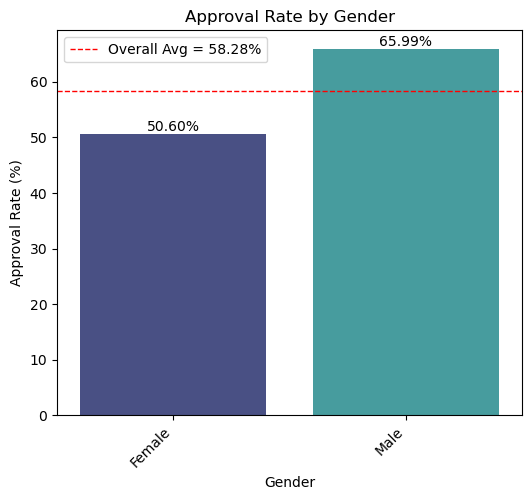

Difference in approval rates (Male − Female): 15.39 percentage points


In [23]:
# Calculate overall approval rate
overall_rate = df["decision.loan_approved"].mean()
overall_rate_percent = (overall_rate * 100).round(2).astype(str) + "%"

print("Overall approval rate:", overall_rate_percent)
# Approval summary by gender
gender_summary = pd.crosstab(
    df["applicant_info.gender"],
    df["decision.loan_approved"]
)

gender_summary.columns = ["Rejected", "Approved"]

# Add totals
gender_summary["Total"] = gender_summary["Rejected"] + gender_summary["Approved"]

# Add approval rate %
gender_summary["Approval Rate (%)"] = (
    gender_summary["Approved"] / gender_summary["Total"] * 100
).round(2)

display(gender_summary)

# Plotting 
plot_df = gender_summary.reset_index().rename(columns={"index": "applicant_info.gender"})

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    data=plot_df,
    x="applicant_info.gender",
    y="Approval Rate (%)",
    hue="applicant_info.gender",
    palette="mako",
    legend=False
)

for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center"
    )

plt.axhline(
    float(overall_rate_percent.replace("%", "")),
    color="red",
    linestyle="--",
    linewidth=1,
    label=f"Overall Avg = {overall_rate:.2%}"
)

plt.legend(loc="best")

plt.xticks(rotation=45, ha='right')
plt.title("Approval Rate by Gender")
plt.ylabel("Approval Rate (%)")
plt.xlabel("Gender")
plt.show()


female_rate = gender_summary.loc["Female", "Approval Rate (%)"]
male_rate = gender_summary.loc["Male", "Approval Rate (%)"]

rate_diff = male_rate - female_rate

print(f"Difference in approval rates (Male − Female): {rate_diff:.2f} percentage points")

- The loan approval rate for male candidates is 65.99%, whilst the approval rate for female applicants is 50.60%, a gap in loan acceptance between gender groups.
- The dataset also shows a nearly equal distribution of applications by gender (251 females vs. 247 males), indicating that sample imbalance is unlikely to be the cause of the discrepancy.

### 4.2 Disparate Impact

In [31]:
# Compute DI (privileged group = male)
female_rate = gender_summary.loc["Female", "Approval Rate (%)"] / 100
male_rate = gender_summary.loc["Male", "Approval Rate (%)"] / 100

disparate_impact = female_rate / male_rate


print(f"Male approval rate: {male_rate:.2%}")
print(f"Female approval rate: {female_rate:.2%}")
print(f"Disparate Impact (%): {disparate_impact*100:.2f}%")


Male approval rate: 65.99%
Female approval rate: 50.60%
Disparate Impact (%): 76.68%


- A DI below 80% indicates a possible negative impact on the underprivileged group (in this case, female candidates) according to the four-fifths rule. If below this threshold, it means that approval rates for women are less than 80% of that for men.
- Loan approval rates fall short of the four-fifths criteria (76.68% is less than 80%). This offers evidence of possible gender-based disparities in the approval process.

### 4.3 Demographic Parity Difference

In [41]:
from fairlearn.metrics import demographic_parity_difference

df_dpd_gender = df[df["applicant_info.gender"].notna() & df["decision.loan_approved"].notna()].copy()
df_dpd_gender["loan_approved_int"]= df_dpd_gender["decision.loan_approved"].astype(int)

dpd_gender = demographic_parity_difference(
    y_true=df_dpd_gender["loan_approved_int"],
    y_pred=df_dpd_gender["loan_approved_int"],
    sensitive_features=df_dpd_gender["applicant_info.gender"]
)

print(f"Demographic Parity Difference: {dpd_gender*100:.2f}%")

Demographic Parity Difference: 15.39%


- The demographic parity difference is defined as the difference between the largest and the smallest group-level selection rate.
- A difference between the highest and lowest group-level selection rate up to 0.1 is often considered fair.
- The calculated DPD is 15.39% and this kind of discrepancy suggests that there may be a gender fairness concern.

### 4.4 Statistical Significance

In [40]:
# Creating contigency table 
table = pd.crosstab(df["applicant_info.gender"], df["decision.loan_approved"])

# perform chi-squared test
stat, p, dof, expected = stats.chi2_contingency(table)


# print results
print("Contingency table:")
print(table)

print(f"Chi-squared Statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

# interpret p-value
alpha = 0.05

print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')




Contingency table:
decision.loan_approved  False  True 
applicant_info.gender               
Female                    124    127
Male                       84    163
Chi-squared Statistic: 11.5053
P-value: 0.0007
p value is 0.0006939983289861307
Dependent (reject H0)


- To determine if approval results were statistically related to gender and significant, we employed a chi-square test of independence, where the null hypothesis (H0) is that loan approval is independent of gender.
- The results of the chi-square test of independence were:
    - χ²(1) = 11.50
    - p = 0.00069
- The findings suggest that gender and loan acceptance rates are statistically significantly associated, according to the chi-square test of independence (χ²(2) = 11.50, p < 0.05). This implies that random variation is unlikely to be the cause of the observed difference.